Project 1

Team: Shuban Iyer(shubani2), Yogi Patel(ypate68), Swarit(swaritt2)

In [56]:
#Currently opening the pickle file using rb and load in order to not edit the data set.
#Need to have the proper imports needed to import from pkle 
#Also want to import numpy in order to help with list functions

import pickle as pkl
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
loaded = pkl.load(open('delta_a100_gpu_xid_dataset.pkl', 'rb'))

In [2]:
# Then using loaded, we would like to parse through to find XID errors observed on March 10th, 2024
# XID errors are stored in a list, so can use len to find the number of elements in it
# We also want to find the list of unique XID 
march_10 = loaded['2024-03-10']
print("Number of XID Errors: ", len(march_10)) # this gives us the amount of XID errors for that date

unique_errors = list({errors['XID'] for errors in march_10})
print("Unique XID Errors: ", unique_errors)

Number of XID Errors:  87
Unique XID Errors:  [74, 43, 45, 13, 119, 31]


In [3]:
# creating pandas dataframe to access data
rows = []

# flattening logs down to rows for the dataframe
for date, logs in loaded.items():
    for log in logs:
        entry_row = {
            'Date': date,
            'Datetime': log.get('datetime'),
            'Timestamp': log.get('timestamp'),
            'Node name': log.get('node_name'),
            'Device ID': log.get('device_id'),
            'XID': log.get('XID'),
            'Tag': log.get('Tag')
        }
        rows.append(entry_row)

dataframe = pd.DataFrame(rows)

# sorting dataframe according to 'Timestamp' in increasing order
# 1. first need to cast each 'Timestamp' value as an integer 
# 2. sort by new 'Timestamp' column value

dataframe['Timestamp'] = pd.to_numeric(dataframe['Timestamp'])
dataframe = dataframe.sort_values(by='Timestamp', ascending=True)

# Task 0 completed


In [4]:
top_ten_rows = dataframe.head(10)
print("Top 10 Rows in Dataframe")
display(top_ten_rows)

first_unix = dataframe.head(1)['Timestamp'].values
first_datetime =  dataframe.head(1)['Datetime'].values

print("First UNIX Timestamp:", first_unix)
print("First Human-readable Datetime:", first_datetime)
# 1.1 completed


Top 10 Rows in Dataframe


,Date,Datetime,Timestamp,Node name,Device ID,XID,Tag
0,2022-07-17,2022-07-17T10:27:27.422837-05:00,1.658072e+09,gpua088,0000:c7:00,119,119_GSP_RPC_timeout
1,2022-07-17,2022-07-17T10:29:29.304632-05:00,1.658072e+09,gpua048,0000:07:00,45,045_GPU_PREEMPTIVE_CLEANUP
2,2022-07-17,2022-07-17T11:03:11.093546-05:00,1.658074e+09,gpua001,0000:85:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
3,2022-07-17,2022-07-17T11:04:15.807907-05:00,1.658074e+09,gpua044,0000:85:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
4,2022-07-17,2022-07-17T11:10:53.818266-05:00,1.658074e+09,gpua045,0000:07:00,43,043_GPU_STOPPED_PROCESSING
5,2022-07-17,2022-07-17T11:16:30.534940-05:00,1.658075e+09,gpua001,0000:c7:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
6,2022-07-17,2022-07-17T11:27:40.849346-05:00,1.658075e+09,gpua001,0000:c7:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
7,2022-07-17,2022-07-17T12:10:20.898006-05:00,1.658078e+09,gpua072,0000:85:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
8,2022-07-17,2022-07-17T13:21:30.008143-05:00,1.658082e+09,gpua081,0000:85:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
9,2022-07-17,2022-07-17T13:21:34.279469-05:00,1.658082e+09,gpua005,0000:c7:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION


First UNIX Timestamp: [1.65807165e+09]
First Human-readable Datetime: ['2022-07-17T10:27:27.422837-05:00']


In [5]:
n = len(dataframe) # total entries
ct_43 = len(dataframe[dataframe['XID'] == 43])
ct_119 = len(dataframe[dataframe['XID'] == 119])

print("1.2a Probability of XID 43, P(XID 43):", ct_43/n)
print("1.2b Probability of XID 119, P(XID 119):", ct_119/n)
print("1.2c: Since P(XID 43) > P(XID 119), the system is significantly more likely to encounter user errors.")
# completed 1.2c

1.2a Probability of XID 43, P(XID 43): 0.11687569714612182
1.2b Probability of XID 119, P(XID 119): 0.017724515058356233
1.2c: Since P(XID 43) > P(XID 119), the system is significantly more likely to encounter user errors.


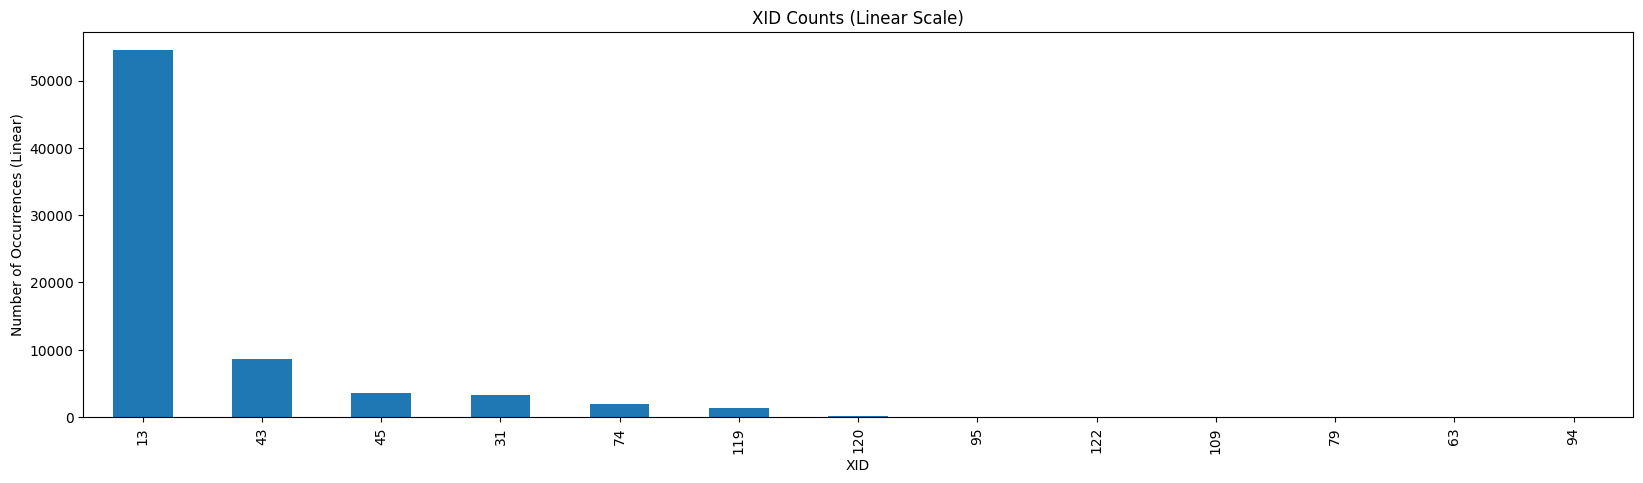

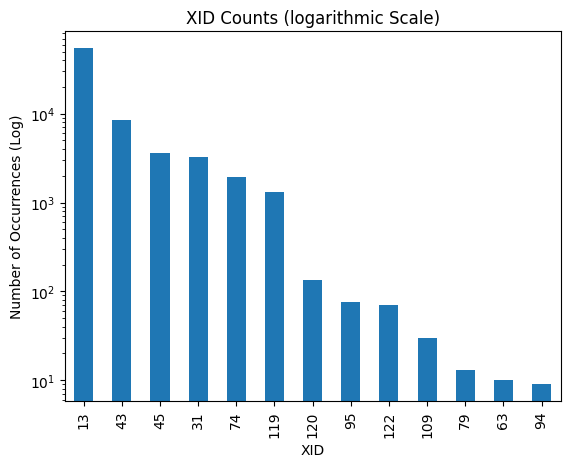

In [6]:
# first sort all XID's by the amount of times they appear
sorted_xid = dataframe['XID'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(20, 5))

# linear scale
sorted_xid.plot(kind='bar')
plt.title('XID Counts (Linear Scale)')
plt.xlabel('XID')
plt.ylabel('Number of Occurrences (Linear)')
plt.show()

# logarithmic scale
sorted_xid.plot(kind='bar')
plt.yscale('log')
plt.title('XID Counts (logarithmic Scale)')
plt.xlabel('XID')
plt.ylabel('Number of Occurrences (Log)')
plt.show()

In [7]:
dominant = sorted_xid.head(1)
print("Most Dominant XID Error")
display(dominant)
# 1.4a

top_5 = sorted_xid.head(5)
print("\nTop 5 XID Errors")
display(top_5)
# 1.4b

print("According to Table 1 in the study, the fifth most frequent error is XID 74, "
      "which is categorized as an interconnect error. Its tag is NVLink Error, "
      "described as a connection issue between GPUs via the NVLink interconnection.")
# 1.4c

Most Dominant XID Error


XID
13    54478
Name: count, dtype: int64


Top 5 XID Errors


XID
13    54478
43     8592
45     3602
31     3272
74     1922
Name: count, dtype: int64

According to Table 1 in the study, the fifth most frequent error is XID 74, which is categorized as an interconnect error. Its tag is NVLink Error, described as a connection issue between GPUs via the NVLink interconnection.


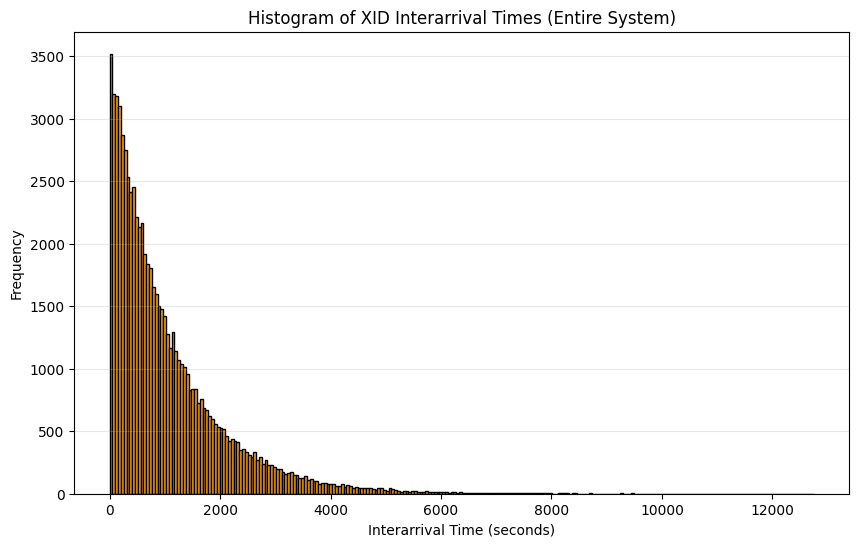

Mean:  1054.4875208708004
Standard Deviation:  1061.687541810317
On average, a job can run for 1054.4875208708004 seconds before an interruption.


In [8]:
interarrival_times = dataframe['Timestamp'].diff()

plt.figure(figsize=(10, 6))
plt.hist(interarrival_times, bins=250, color='orange', edgecolor='black')
plt.title('Histogram of XID Interarrival Times (Entire System)')
plt.xlabel('Interarrival Time (seconds)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()
# 1.5a

mean = interarrival_times.mean()
standard_dev = interarrival_times.std()
print("Mean: ", mean)
print("Standard Deviation: ", standard_dev)
# 1.5b

print("On average, a job can run for", mean, "seconds before an interruption.")
# 1.5c

In [9]:
#Want to use the Goodness of Fit Function from Scipy in order to test what distribution the 
#Interarrival Times of the XID are. 
from scipy import stats

# print("Test")

interarrival_times = interarrival_times.dropna() # Want to remove NAN values from interarrival times

# A: Exponential Distribution 
results_exponential = stats.goodness_of_fit(stats.expon, interarrival_times, statistic='ks', n_mc_samples=1000)
print("The p value for the exponential tests is ", results_exponential.pvalue)
print("The statistics for the exponential test is ", results_exponential.statistic)
print("The fitted paramters for exponential are ", results_exponential.fit_result.params)

#B: Normal Distribution 
results_normal = stats.goodness_of_fit(stats.norm, interarrival_times, statistic='ks', n_mc_samples=1000)
print("The p value for the normal tests is ", results_normal.pvalue)
print("The statistics for the normal test is ", results_normal.statistic)
print("The fitted paramters for normal are ", results_normal.fit_result.params)

#C: Uniform Distribution 
results_uniform = stats.goodness_of_fit(stats.uniform, interarrival_times, statistic='ks', n_mc_samples=1000)
print("The p value for the uniform tests is ", results_uniform.pvalue)
print("The statistics for the uniform test is ", results_uniform.statistic)
print("The fitted paramters for uniform are ", results_uniform.fit_result.params)

#D: Lognormal Distribution
results_logNormal = stats.goodness_of_fit(stats.lognorm, interarrival_times, known_params={'loc': 0}, statistic='ks', n_mc_samples=1000)
print("The p value for the lognormal tests is ", results_logNormal.pvalue)
print("The statistics for the lognormal test is ", results_logNormal.statistic)
print("The fitted paramters for lognormal are ", results_logNormal.fit_result.params)


The p value for the exponential tests is  0.4015984015984016
The statistics for the exponential test is  0.0027587078476604687
The fitted paramters for exponential are  FitParams(loc=np.float64(0.011411905288696289), scale=np.float64(1054.4761089655117))
The p value for the normal tests is  0.000999000999000999
The statistics for the normal test is  0.160304403757268
The fitted paramters for normal are  FitParams(loc=np.float64(1054.4875208708004), scale=np.float64(1061.687541810317))
The p value for the uniform tests is  0.000999000999000999
The statistics for the uniform test is  0.7107835116555101
The fitted paramters for uniform are  FitParams(loc=np.float64(0.011411905288696289), scale=np.float64(12756.949822425842))
The p value for the lognormal tests is  0.000999000999000999
The statistics for the lognormal test is  0.07109998037689813
The fitted paramters for lognormal are  FitParams(s=np.float64(1.282634637321251), loc=np.float64(0.0), scale=np.float64(590.989398729418))



## Results from Distribution Test

As we can see from the above tests, the distributions which produce a  p value less than 0.05 are normal, uniform, and loganormal wheras the exponential distribution produces the highest p value. As a result, the best fit distribution is the exponential disribution. Given the scale parameter, we can 
find the corresponding lambda

## Part 1 Question 7 

1) Given that the probability distribution of the interarrival times is exponentials, the probability distribution that measures the number of arrivals in a time interval should be Poisson. 

2) The parameters are lambda, which is the average number of arrivals for the time interval, and k which is the number of arrivals. In this case, our lambda is 1/scale, which is 1/1054.48. 

3) For the model to work as expected, we would need for CDF(5) to be at least 0.8. This equates to the probability of 5 arrivals minus the probability of 0 arrivals. Since the time interval is 1 hour, we multiply by 3600 to get the time interval. As such, our Lambda is 3600 * (1/scale). Computing this gives us a Lambda of ~ 3.414. Using poisson distribution CDF, we have P(x<=5) ~ 0.863, which passes the 80 percent threshold set by the SLO requirement. As such, the system meets the users requirements.

## Part 2 Question 1

1) The interarrival times distribution is exponential distribution, with parameter lambda being equal to 1/1054.48. Our answer agrees with the TA, because we found that the distribution should be exponential. 

In [10]:
# Part 2 Question 3 requires finding the number of operational hours, over the the number of 
# failure events

#Each XID is considered a failure event, find length of XIDs in panda dataframe
#Find number of days, multiply by 24 hours 
#We find the number of days by taking length of the 

xid_length = dataframe['XID'].count()
num_of_hours = len(dataframe['Date'].unique()) * 24

#Divide to obtain MTTF
mtbf = num_of_hours/xid_length # dividing by total amount of hours vs the xid_length
print("The MTBF in hours is ", mtbf)

#Obtain in terms of seconds 
# this is an empirical conversion by multplying by 3600 to get it in terms of seconds, as it is 3600 seconds / 1 hours
mtbf_seconds = mtbf * 3600

print("The MTBF in seconds is ", mtbf_seconds)





The MTBF in hours is  0.29316864814865196
The MTBF in seconds is  1055.4071333351471


In [11]:
#Part 2 question 4 is finding the expected value of the mean time failure using the lambda we derived 
# from earlier. We know that the expected value of an exponential distribution is 1/lambda 
#given that lambda is equal to 1/lambda 

lamb = 1/1054.48 # We set the lamb value to get 1/scale 

expected_value_exp = 1/lamb # expected value calculated as such

print("Distribution Mean Time Between Failures ", expected_value_exp)



Distribution Mean Time Between Failures  1054.48


## Part 2 Question 4 

1) As we can see from the MTBF in seconds calculated empirically is very close to the expected value given from the exponential distribution. Thus, the fitted parameter given for the exponential distribution is true to the empirical data. 

2) The relation we found is not enough to establish that exponential distribution is a good fit, because the MTBF is just one statistic which only captures the mean and not the shape of the distribution. Another statistic which we calculated is the KS statistic and the p value, which both showed good results that demonstrated that exponential distribution is a good fit for the data's distribution

Number of unique interarrival time values: 73512
First 10 unique times: [0.01141191 0.0275631  0.05462003 0.06886816 0.08463407 0.10743761
 0.11227942 0.12138295 0.12173295 0.1219275 ]

First 10 values of H(t):
[0.11506021 1.91353442 0.0616177  0.37756718 0.31959278 0.63821154
 2.41762241 4.01116291 0.0040346  0.39159492]


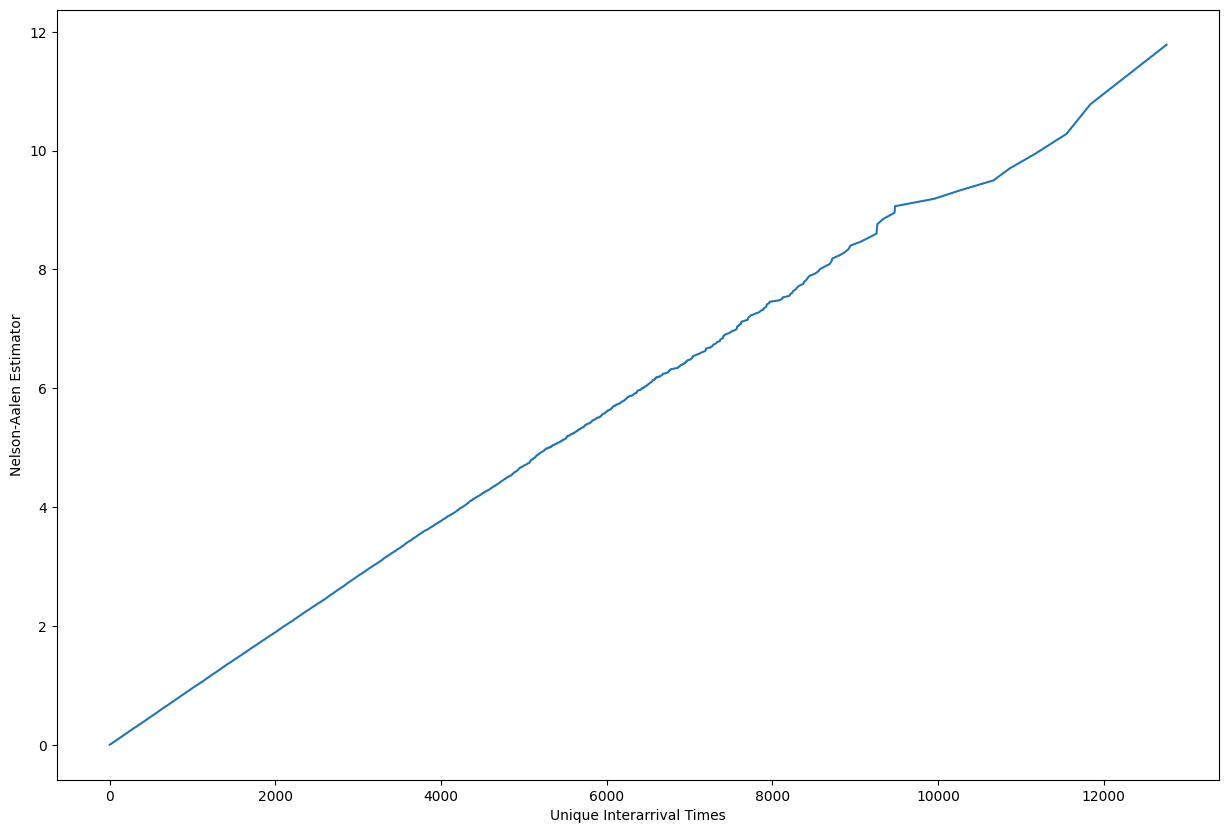

As Seen with the graph, it appears to increase linearly, meaning the cumlative failure rate is linear where as the instantaneous failure rate is constant


In [12]:
#Part 2 Question 5 

#a --> Sort the interarrival times, then find the unique interarrival value times

interarrival_times_clean = interarrival_times.dropna().values
unique_interarrival_times = np.sort(np.unique(interarrival_times_clean))
print(f"Number of unique interarrival time values: {len(unique_interarrival_times)}")
print(f"First 10 unique times: {unique_interarrival_times[:10]}")                                 

#b Want to create the nelson-Aalen estimator function as well as empty array to store values
H = np.zeros(len(interarrival_times_clean))
d_values = np.array([np.sum(interarrival_times_clean == t) for t in unique_interarrival_times])
n_values = np.array([np.sum(interarrival_times_clean >= t) for t in unique_interarrival_times])
cumsum_per_unique = np.cumsum(d_values / n_values)
for i, obs_time in enumerate(interarrival_times_clean):
    # Find which unique times are <= obs_time
    idx = np.searchsorted(unique_interarrival_times, obs_time, side='right') - 1
    H[i] = cumsum_per_unique[idx] if idx >= 0 else 0

print("\nFirst 10 values of H(t):")
print(H[:10])

#c Plot the estimated cumulative hazard function Ĥ(𝑡) versus the corresponding timestamps
plt.figure(figsize=(15,10))
plt.plot(unique_interarrival_times, cumsum_per_unique)
plt.xlabel("Unique Interarrival Times")
plt.ylabel("Nelson-Aalen Estimator")
plt.show()

print("As Seen with the graph, it appears to increase linearly, meaning the cumlative failure rate is linear" \
" where as the instantaneous failure rate is constant")

## Part 2 Question 5 D

Based on the computation above, since the instantaneous failure rate is constant, and the iterarrival time is exponentially distributed, it must mean that the system is at its normal life.

In [13]:
# Part 2 Question 5e, estimating average hazard rate from cumulative hazard rate

#What we want to do is fit a line to the unique interarrival times vs Nelson Aalen Estimator plot
#And take the slope from there 

best_fit = np.polyfit(unique_interarrival_times, cumsum_per_unique, 1)
print("Experimental Average Hazard Rate: ", best_fit[[0]])

#We can compare this with the theoretical hazard rate for an exponentially distributed function, 
# lambda 
print("Theoretical Average Hazard Rate ", lamb)


Experimental Average Hazard Rate:  [0.00094179]
Theoretical Average Hazard Rate  0.0009483347242242622


#

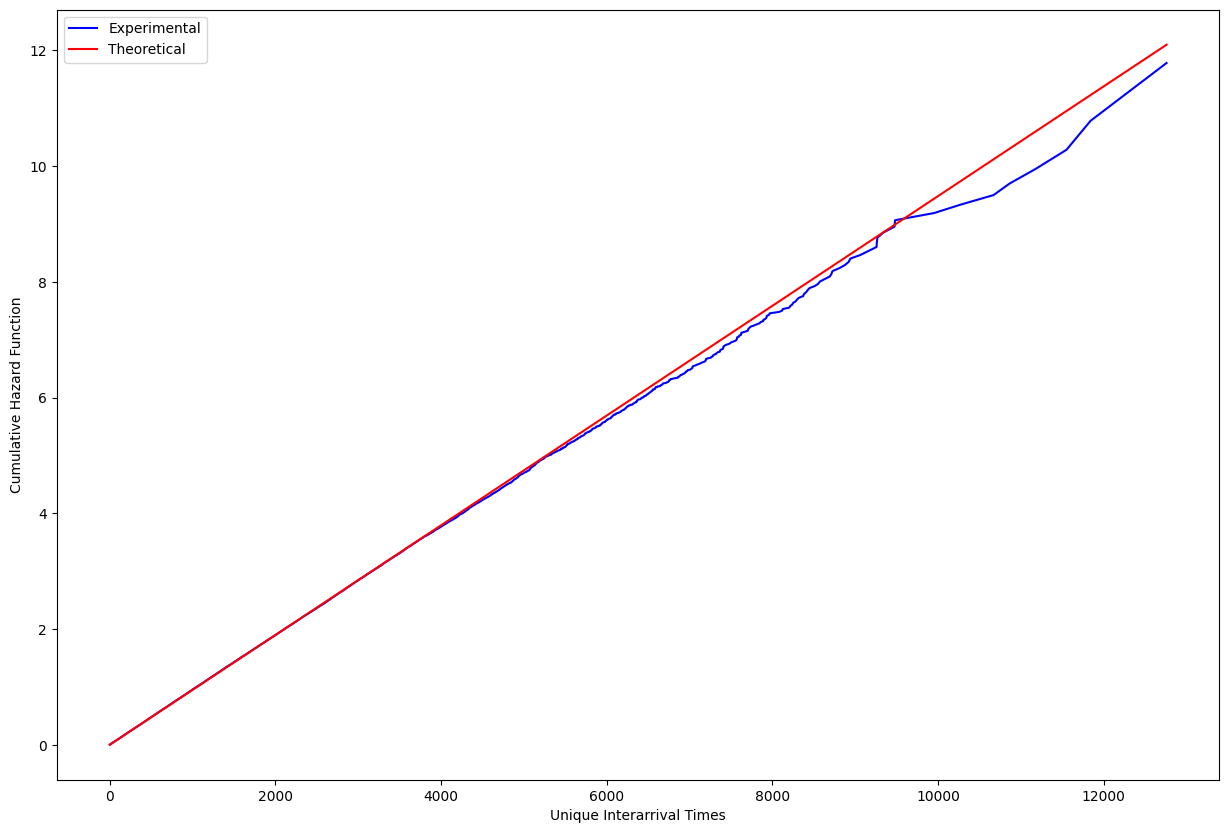

In [14]:
#Part 2 Question 5f, comparing theoretical vs experimental cumulative hazard function 

#We know for an exponential function, that the hazard rate is just lambda. As such, the cumulative hazard
#function is lambda * t for every unique t in the interrarival times. We can plot this over our cumulative
# hazard function we got from the Nelson Aalen Estimator. 

plt.figure(figsize=(15,10))
plt.plot(unique_interarrival_times, cumsum_per_unique, "-b", label = "Experimental")
plt.plot(unique_interarrival_times, unique_interarrival_times * lamb, "-r", label = "Theoretical")
plt.legend()
plt.xlabel("Unique Interarrival Times")
plt.ylabel("Cumulative Hazard Function")
plt.show()


## Part 2 Question 5 g

From the previous cells, we can compare the theoretical hazard rate (0.000948) vs the Nelson - Aelen estimated hazard rate (0.000942) and see that they are practically equal; This is consistent as we wanted to show our interarrival time is exponentially distributed, and in which the theoretical hazard rate then should be our lambda, which the estimated hazard rate is close to. This is further demonstrated by looking at the cumulative hazard function for both cases, which are also very similar albeit for a slight deviation in the later interarrival times. This is consistent in both our assumption and our data showing that the interarrival times are exponentially distributed. 

In [15]:
#Part 3 Question 1A

#In this part, we need to load the dataset, and make sure to remove duplicates
#Duplicates are constitued as having the name node, same Device ID, same XID, time within 5
# And no nodes in between 

loaded_2 = pkl.load(open('delta_a100_gpu_xid_dataset_with_noise.pkl', 'rb'))

#moving the code into pandas for easier data_acess
rows_2 = []
# flattening logs down to rows for the dataframe
for date, logs in loaded_2.items():
    for log in logs:
        entry_row = {
            'Date': date,
            'Datetime': log.get('datetime'),
            'Timestamp': log.get('timestamp'),
            'Node name': log.get('node_name'),
            'Device ID': log.get('device_id'),
            'XID': log.get('XID'),
            'Tag': log.get('Tag')
        }
        rows_2.append(entry_row)

dataframe_2 = pd.DataFrame(rows_2)

dataframe_2['Timestamp'] = pd.to_numeric(dataframe_2['Timestamp'])

def deduplicate(group):
    group = group.sort_values('Timestamp')
    kept = []
    anchor = None
    for _, row in group.iterrows():
        if anchor is None:
            kept.append(row.to_dict())
            anchor = (row['Timestamp'], row ['XID'])
        else:
            same_xid = (row['XID'] == anchor[1])
            time_diff = (row['Timestamp'] - anchor[0]) <= 5
            if same_xid and time_diff:
                continue
            else:
                kept.append(row.to_dict())
                anchor = (row['Timestamp'], row['XID'])
    return pd.DataFrame(kept, columns=group.columns)

dataframe_2_clean = dataframe_2.groupby(['Node name', 'Device ID'], group_keys=False, as_index=False).apply(deduplicate)
print(dataframe_2_clean.columns.to_list())
duplicate_count = len(dataframe_2) - len(dataframe_2_clean)

print(f"Removed {duplicate_count} duplicate entries ")
print(f"Percentage of Duplicates is {duplicate_count/len(dataframe_2)}")




['Date', 'Datetime', 'Timestamp', 'Node name', 'Device ID', 'XID', 'Tag']
Removed 12751 duplicate entries 
Percentage of Duplicates is 0.13484987890901784


/var/folders/cg/ckjhb_dx7xj8blz6plnb6_p00000gn/T/ipykernel_16997/3785927924.py:47: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dataframe_2_clean = dataframe_2.groupby(['Node name', 'Device ID'], group_keys=False, as_index=False).apply(deduplicate)


/var/folders/cg/ckjhb_dx7xj8blz6plnb6_p00000gn/T/ipykernel_16997/1089584528.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dataframe_2_clean = dataframe_2.groupby(['Node name', 'Device ID'], group_keys=False, as_index= False).apply(deduplicate_xid_count)


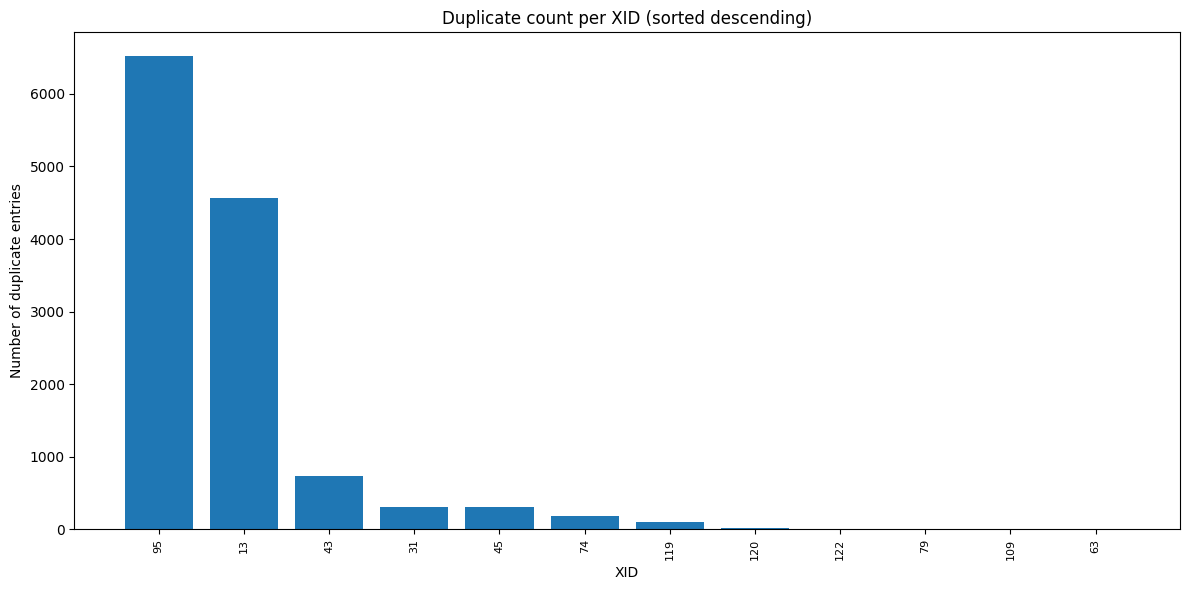

The top 5 XIDs with the highest duplicate count include 
 XID 95: 6520 duplicates
 XID 13: 4558 duplicates
 XID 43: 735 duplicates
 XID 31: 313 duplicates
 XID 45: 311 duplicates
The percentage of duplicates from the top 5 is 0.9753744804329072


In [16]:
#Part 3 Question 1B

#We want to plot a histogram for the counts of duplication based on XID
from collections import Counter

duplicate_xid_count = Counter()

def deduplicate_xid_count(group):
    group = group.sort_values('Timestamp')
    kept = []
    anchor = None
    for _, row in group.iterrows():
        if anchor is None:
            kept.append(row)
            anchor = (row['Timestamp'], row['XID'])
        else:
            same_xid = (row['XID'] == anchor[1])
            within_5s = (row['Timestamp'] - anchor[0]) <= 5
            if same_xid and within_5s:
                duplicate_xid_count[row['XID']] += 1   # count this duplicate
            else:
                kept.append(row)
                anchor = (row['Timestamp'], row['XID'])
    return pd.DataFrame(kept)

dataframe_2_clean = dataframe_2.groupby(['Node name', 'Device ID'], group_keys=False, as_index= False).apply(deduplicate_xid_count)

dup_counts_df = pd.DataFrame(list(duplicate_xid_count.items()), 
                              columns=['XID', 'duplicate_count'])
dup_counts_df = dup_counts_df.sort_values('duplicate_count', ascending=False)

# Bar chart: XID on x-axis, duplicate count on y-axis, descending height
plt.figure(figsize=(12, 6))
plt.bar(dup_counts_df['XID'].astype(str), dup_counts_df['duplicate_count'])
plt.xlabel('XID')
plt.ylabel('Number of duplicate entries')
plt.title('Duplicate count per XID (sorted descending)')
plt.xticks(rotation=90, fontsize=8)  # rotate if many XIDs
plt.tight_layout()
plt.show()

top5 = duplicate_xid_count.most_common(5)

print(f'The top 5 XIDs with the highest duplicate count include ')
for xid, cnt in top5:
    print(f' XID {xid}: {cnt} duplicates')

total = sum(duplicate_xid_count.values())
top_5 = sum(cnt for _, cnt in top5)
print(f'The percentage of duplicates from the top 5 is {top_5/total}')



In [17]:
#Part 3 Question 1 C
print(f'The number of non duplicates remaining is {len(dataframe_2_clean)}')

The number of non duplicates remaining is 81806


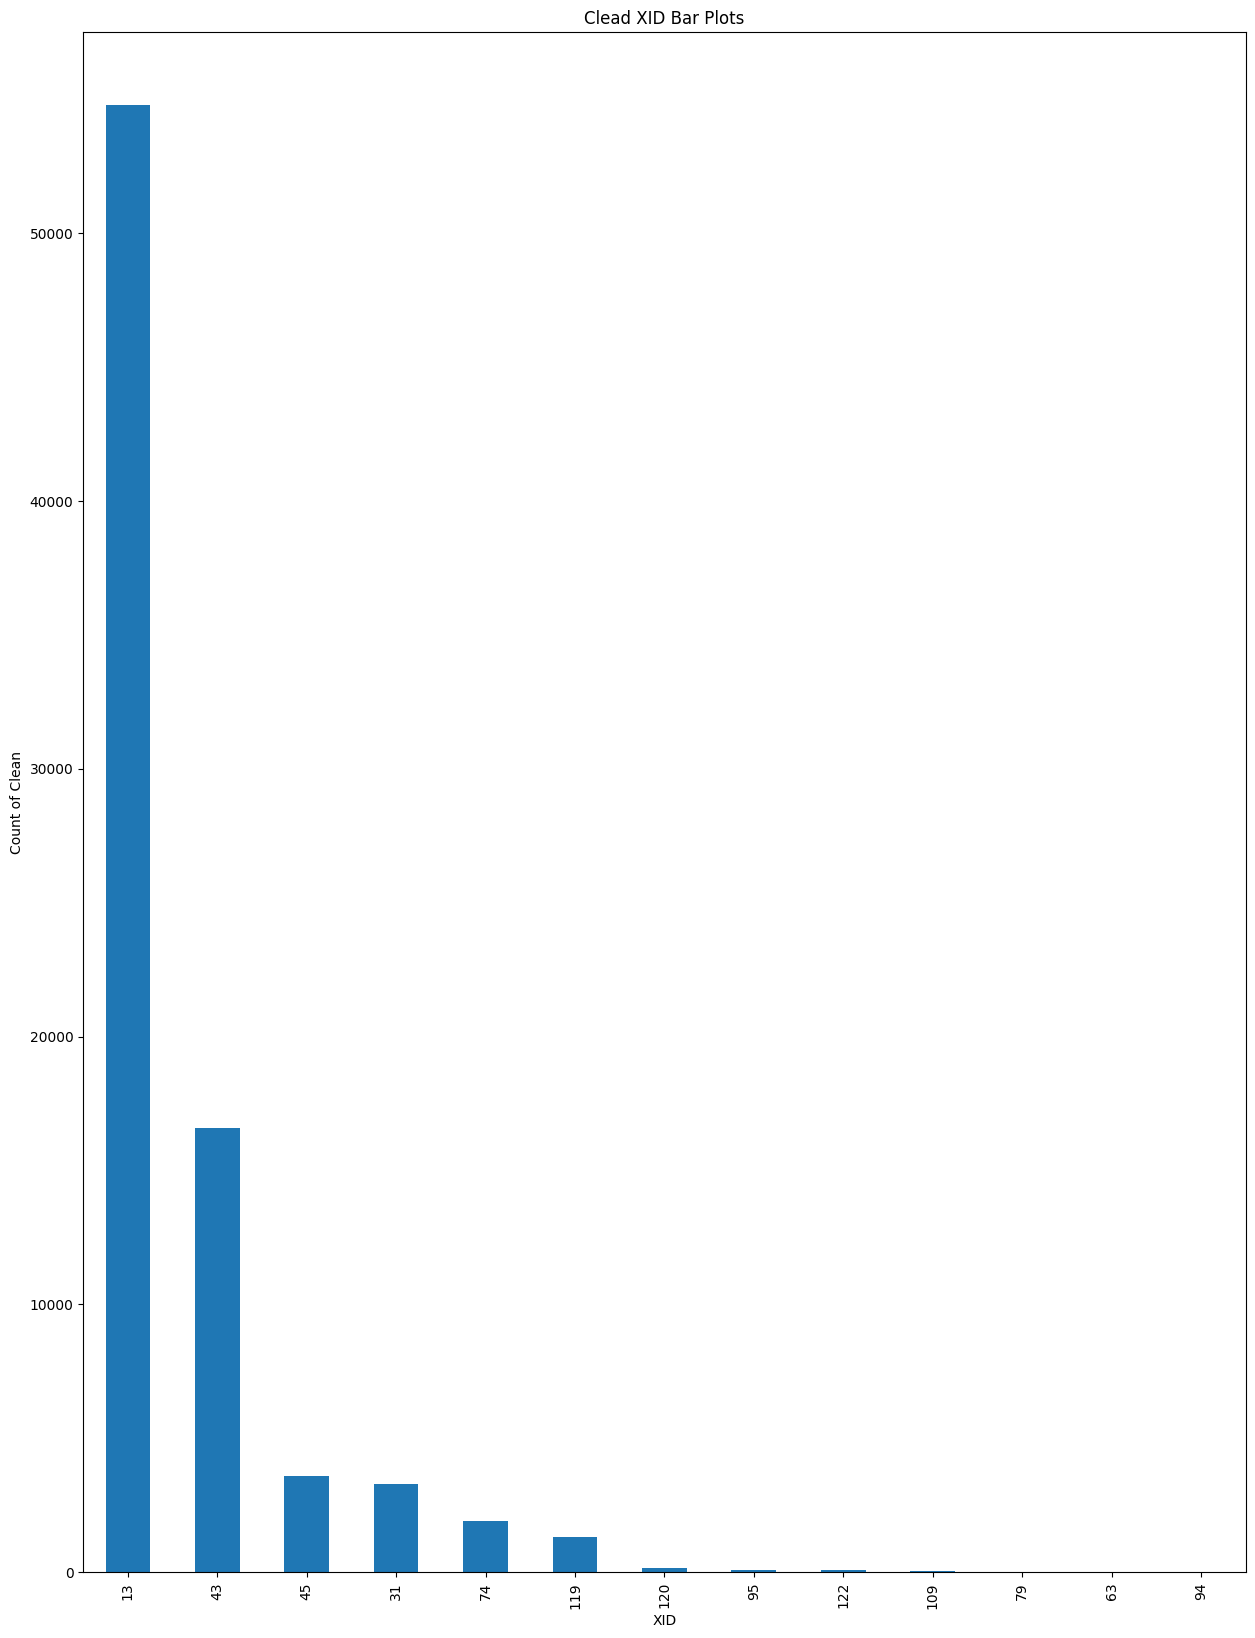

The highest counts for the clean data are (13, 43, 35, 31, 74)
We see that 95 is not in the top 5 anymore, meaning that XID 95 is an issue which either messes with the logs or does not have clean tracking


In [18]:
#Part 3 Question1 D

#Looking for top 5 XID in the clean data_frame

clean_xid = dataframe_2_clean['XID'].value_counts()

plt.figure(figsize= (15,20))

clean_xid.plot(kind = 'bar')
plt.title('Clead XID Bar Plots')
plt.xlabel('XID')
plt.ylabel('Count of Clean')
plt.show()

print(f'The highest counts for the clean data are {13, 43, 35, 31, 74}')

print('We see that 95 is not in the top 5 anymore, meaning that XID 95 is an issue which either' \
' messes with the logs or does not have clean tracking')

/var/folders/cg/ckjhb_dx7xj8blz6plnb6_p00000gn/T/ipykernel_16997/686649999.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  temp_df = dataframe_2.groupby(['Node name', 'Device ID'], group_keys=False, as_index= False).apply(lambda group: deduplicate_count(group, i)).reset_index(drop=True)
/var/folders/cg/ckjhb_dx7xj8blz6plnb6_p00000gn/T/ipykernel_16997/686649999.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
 

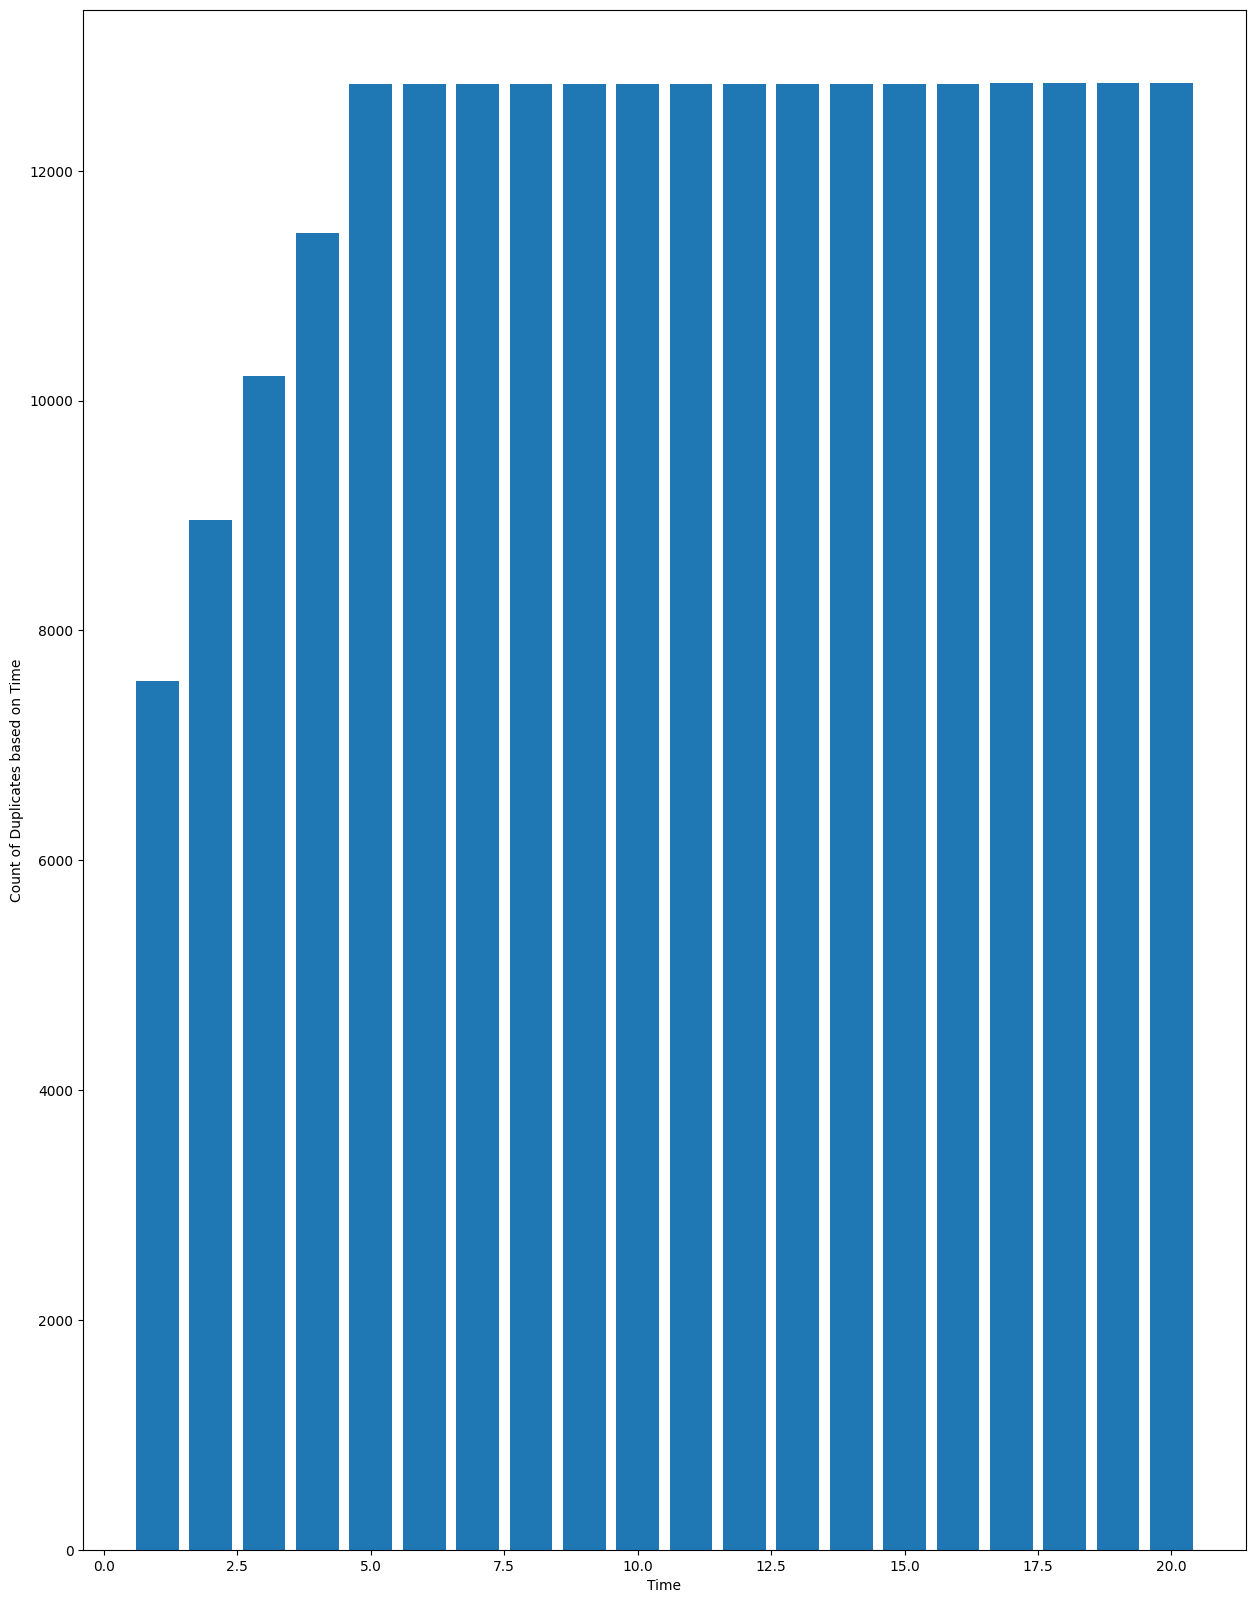

As observed from the plot, at 5 seconds the amount of duplicates are equivalent. As such, I would select a window length of 5.


In [19]:
#Part 3, Question 2 

#This part focuses on printing the number of duplicates from window range between 1 - 20 seconds

duplicates_count = []

def deduplicate_count(group, time):
    group = group.sort_values('Timestamp')
    kept = []
    anchor = None
    for _, row in group.iterrows():
        if anchor is None:
            kept.append(row)
            anchor = (row['Timestamp'], row ['XID'])
        else:
            same_xid = (row['XID'] == anchor[1])
            time_diff = (row['Timestamp'] - anchor[0]) <= time
            if same_xid and time_diff:
                continue
            else:
                kept.append(row)
                anchor = (row['Timestamp'], row['XID'])
    return pd.DataFrame(kept)


for i in range(1, 21):
  temp_df = dataframe_2.groupby(['Node name', 'Device ID'], group_keys=False, as_index= False).apply(lambda group: deduplicate_count(group, i)).reset_index(drop=True)
  duplicates_count.append(len(dataframe_2) - len(temp_df))


plt.figure(figsize=(15,20))
plt.bar(range(1,21), duplicates_count)
plt.xlabel('Time')
plt.ylabel('Count of Duplicates based on Time')
plt.show()

print("As observed from the plot, at 5 seconds the amount of duplicates are equivalent. As such, I would select a window length of 5.")

In [21]:
#Task 3 Part 3

#Want to check for coalesced pairs 

# print(dataframe_2_clean.columns.tolist())
dataframe_2_clean = dataframe_2_clean.reset_index(drop=True)
dataframe_2_clean = dataframe_2_clean.sort_values(by = 'Timestamp', ascending=True)


coalesced_13 = 0
coalesced_43 = 0

def coaleseced(group):
    global coalesced_13, coalesced_43
    group = group.sort_values('Timestamp')

    kept = []
    anchor_time = None
    anchor_xid = None

    for _, row in group.iterrows():
        curr_time = row['Timestamp']
        curr_xid = row['XID']

        if anchor_time is None:
            kept.append(row.to_dict())
            anchor_time = curr_time
            anchor_xid = curr_xid
            continue

        time_diff = curr_time - anchor_time

        # 🔹 Rule 1: Deduplication (same XID within 5 sec)
        is_duplicate = (curr_xid == anchor_xid) and (time_diff <= 5)

        # 🔹 Rule 2: Coalescing (13 ↔ 43 within 5 sec)
        is_coalesced_pair = (
            ((curr_xid == 13 and anchor_xid == 43) or
             (curr_xid == 43 and anchor_xid == 13))
            and time_diff <= 5
        )

        if is_duplicate:
            continue

        elif is_coalesced_pair:
            if anchor_xid == 13 and curr_xid == 43:
                coalesced_13 = coalesced_13 + 1
            elif anchor_xid == 43 and curr_xid == 13:
                coalesced_43 = coalesced_43 + 1
            continue

        else:
            kept.append(row.to_dict())
            anchor_time = curr_time
            anchor_xid = curr_xid

    result = pd.DataFrame(kept, columns=group.columns)

    return result

dataframe_2_coaleseced = dataframe_2_clean.groupby(['Node name', 'Device ID'], group_keys=False, as_index=False).apply(coaleseced)


print(f'The number of coalesced pairs are {len(dataframe_2_clean) - len(dataframe_2_coaleseced)}')
print(f'The number remaining after the coalesced are {len(dataframe_2_coaleseced)}')


print(f'The number of counts from XID 13 --> 43 is given as {coalesced_13}')
print(f'The number of counts from XID 43 --> 13 is given as {coalesced_43}')

print("Since XID 13 has the majority of the anchor nodes, it means that XID 13 is likely to be the cause wheras 43 is a downstream symptom")



The number of coalesced pairs are 8298
The number remaining after the coalesced are 73508
The number of counts from XID 13 --> 43 is given as 8002
The number of counts from XID 43 --> 13 is given as 0
Since XID 13 has the majority of the anchor nodes, it means that XID 13 is likely to be the cause wheras 43 is a downstream symptom


/var/folders/cg/ckjhb_dx7xj8blz6plnb6_p00000gn/T/ipykernel_16997/2264074142.py:62: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dataframe_2_coaleseced = dataframe_2_clean.groupby(['Node name', 'Device ID'], group_keys=False, as_index=False).apply(coaleseced)


In [26]:
# Task 3 Question 4
# 4a

cluster_df = dataframe_2_coaleseced.copy()
cluster_df = cluster_df.sort_values('Timestamp').reset_index(drop=True)

cluster_ids = [0]

for i in range(1, len(cluster_df)):
    prev_time = cluster_df.loc[i - 1, 'Timestamp']
    curr_time = cluster_df.loc[i, 'Timestamp']
    
    if curr_time - prev_time < 600:
        cluster_ids.append(cluster_ids[-1])
    else:
        cluster_ids.append(cluster_ids[-1] + 1)

cluster_df['Cluster ID'] = cluster_ids

num_clusters = cluster_df['Cluster ID'].nunique()

cluster_sizes = cluster_df.groupby('Cluster ID').size()
single_event_clusters = (cluster_sizes == 1).sum()
multi_event_clusters = (cluster_sizes > 1).sum()

print("Total number of clusters:", num_clusters)
print("Number of single-event clusters:", single_event_clusters)
print("Number of multi-event clusters:", multi_event_clusters)
print("Fraction of clusters that are single-event:", single_event_clusters / num_clusters)
print("Fraction of clusters that are multi-event:", multi_event_clusters / num_clusters)

Total number of clusters: 41497
Number of single-event clusters: 23450
Number of multi-event clusters: 18047
Fraction of clusters that are single-event: 0.5651010916451792
Fraction of clusters that are multi-event: 0.4348989083548208


Cluster size mean: 1.7714051618189266
Cluster size median 1.0
Cluster size maximum 17
Cluster size standard deviation 1.1669442786256579


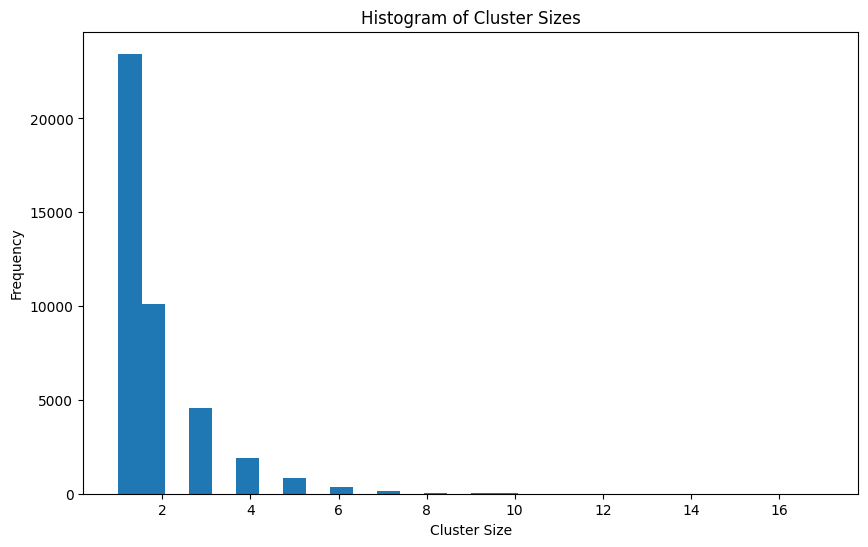

In [35]:
# 4b
cluster_sizes = cluster_df.groupby('Cluster ID').size()

mean_size = cluster_sizes.mean()
median_size = cluster_sizes.median()
max_size = cluster_sizes.max()
std_size = cluster_sizes.std()

print("Cluster size mean:", mean_size)
print("Cluster size median", median_size)
print("Cluster size maximum", max_size)
print("Cluster size standard deviation", std_size)

plt.figure(figsize=(10, 6))
plt.hist(cluster_sizes, bins=30)
plt.xlabel('Cluster Size')
plt.ylabel('Frequency')
plt.title('Histogram of Cluster Sizes')
plt.show()

Cluster duration statistics in seconds:
Mean: 210.15306350918658
Median: 0.0
Maximum: 3719.985488653183
Standard deviation: 351.34639378053674

Cluster duration statistics in hours:
Mean: 0.05837585097477405
Median: 0.0
Maximum: 1.0333293024036618
Standard deviation: 0.09759622049459354


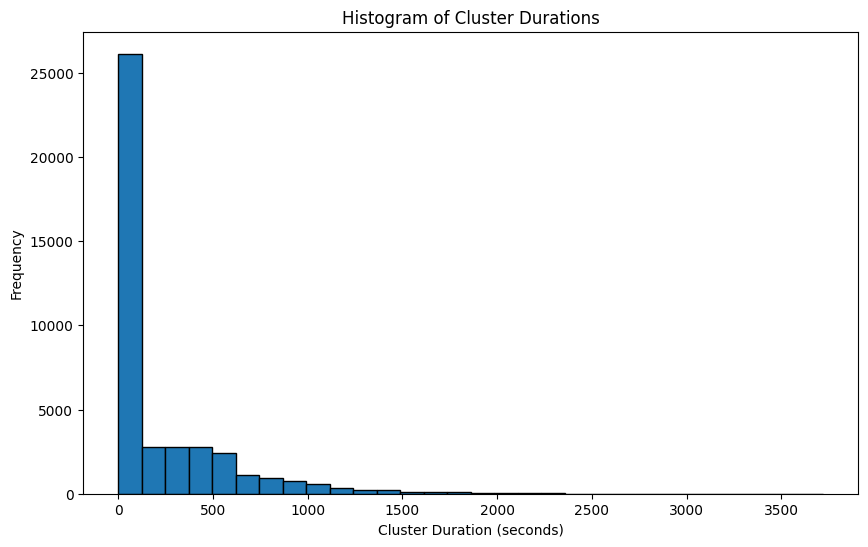

In [42]:
#4c
grouped = cluster_df.groupby('Cluster ID')['Timestamp']
cluster_duration = grouped.max() - grouped.min()

mean_duration_sec = cluster_duration.mean()
median_duration_sec = cluster_duration.median()
max_duration_sec = cluster_duration.max()
std_duration_sec = cluster_duration.std()

print("Cluster duration statistics in seconds:")
print("Mean:", mean_duration_sec)
print("Median:", median_duration_sec)
print("Maximum:", max_duration_sec)
print("Standard deviation:", std_duration_sec)

print("\nCluster duration statistics in hours:")
print("Mean:", mean_duration_sec / 3600)
print("Median:", median_duration_sec / 3600)
print("Maximum:", max_duration_sec / 3600)
print("Standard deviation:", std_duration_sec / 3600)

plt.figure(figsize=(10, 6))
plt.hist(cluster_duration, bins=30, edgecolor='black')
plt.xlabel('Cluster Duration (seconds)')
plt.ylabel('Frequency')
plt.title('Histogram of Cluster Durations')
plt.show()

In [48]:
#4d
multi_cluster_df = cluster_df[cluster_df['Cluster ID'].isin(cluster_sizes[cluster_sizes > 1].index)]

cluster_patterns = multi_cluster_df.groupby('Cluster ID')['XID'].apply(lambda x: tuple(sorted(set(x))))

pattern_counts = cluster_patterns.value_counts().head(5)

print("Top 5 most common order-less unique XID combination patterns:")
for pattern, count in pattern_counts.items():
    print(pattern, ":", count)

Top 5 most common order-less unique XID combination patterns:
(13,) : 8218
(13, 43) : 3586
(13, 45) : 1379
(13, 31) : 1291
(13, 74) : 741


In [52]:
# Task 3 Question 5
#5a

prop_df = dataframe_2_coaleseced.copy()
prop_df = prop_df.sort_values('Timestamp').reset_index(drop=True)

sample_space_V = sorted(prop_df['XID'].unique().tolist())
sample_space_V.append('None')

print("Sample space of V:")
print(sample_space_V)
print("V consists of all possible next XIDs within 600 seconds after XID A, plus 'None' in the case that no next event occurs within 600 seconds.")


Sample space of V:
[13, 31, 43, 45, 63, 74, 79, 94, 95, 109, 119, 120, 122, 'None']
V consists of all possible next XIDs within 600 seconds after XID A, plus 'None' in the case that no next event occurs within 600 seconds.


System-level propagation probability matrix:


,45,31,None,13,43,119,74,120,95,122,109,94,63,79
13,0.020469,0.019092,0.565979,0.321964,0.051182,0.008316,0.011180,0.000808,0.000422,0.000275,0.000239,0.000018,0.000037,0.000018
31,0.018337,0.020171,0.573044,0.312042,0.054707,0.005501,0.014364,0.000611,0.000000,0.000611,0.000000,0.000000,0.000611,0.000000
43,0.022114,0.018622,0.557612,0.329143,0.051909,0.005819,0.012686,0.000815,0.000466,0.000349,0.000233,0.000233,0.000000,0.000000
45,0.023598,0.022210,0.558579,0.318712,0.053859,0.009994,0.011938,0.000278,0.000278,0.000555,0.000000,0.000000,0.000000,0.000000
63,0.000000,0.100000,0.200000,0.600000,0.000000,0.000000,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
74,0.018730,0.020812,0.543184,0.348595,0.049948,0.006764,0.010406,0.000000,0.000520,0.001041,0.000000,0.000000,0.000000,0.000000
79,0.000000,0.000000,0.692308,0.307692,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
94,0.111111,0.111111,0.444444,0.222222,0.111111,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
95,0.039474,0.000000,0.592105,0.289474,0.052632,0.013158,0.013158,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
109,0.000000,0.066667,0.400000,0.433333,0.066667,0.033333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


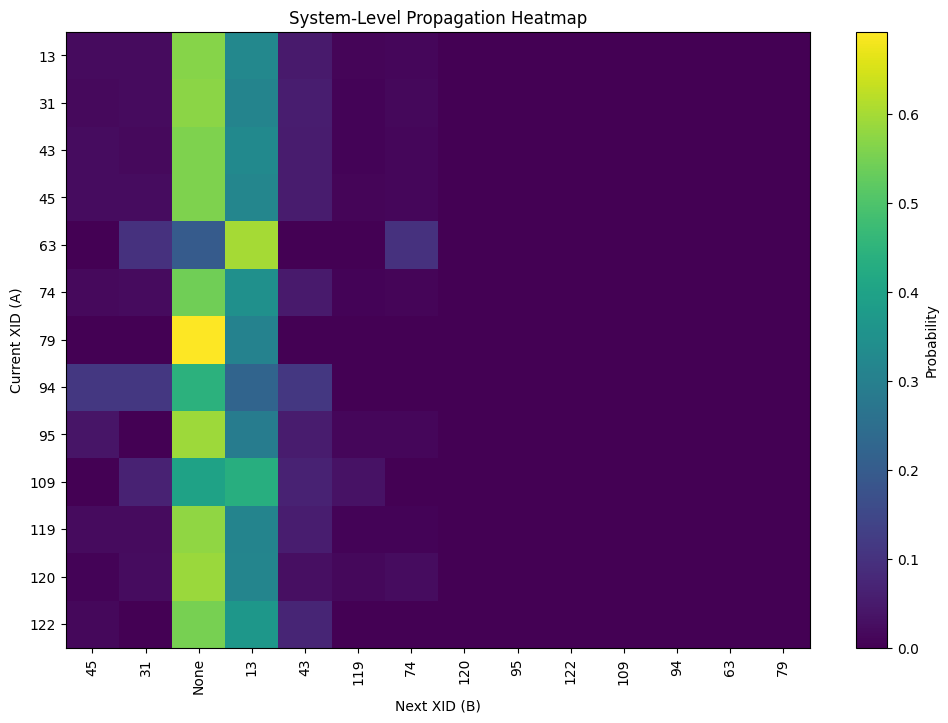

In [59]:
#5b
counts = defaultdict(lambda: defaultdict(int))

for i in range(len(prop_df) - 1):
    curr_xid = prop_df.loc[i, 'XID']
    next_xid = prop_df.loc[i + 1, 'XID']
    
    curr_time = prop_df.loc[i, 'Timestamp']
    next_time = prop_df.loc[i + 1, 'Timestamp']
    
    if next_time - curr_time <= 600:
        counts[curr_xid][next_xid] += 1
    else:
        counts[curr_xid]['None'] += 1

last_xid = prop_df.loc[len(prop_df) - 1, 'XID']
counts[last_xid]['None'] += 1

prob_matrix = {}

for xid_a in counts:
    total = sum(counts[xid_a].values())
    prob_matrix[xid_a] = {}
    for xid_b in counts[xid_a]:
        prob_matrix[xid_a][xid_b] = counts[xid_a][xid_b] / total

prob_df = pd.DataFrame(prob_matrix).fillna(0).T
prob_df = prob_df.sort_index()

print("System-level propagation probability matrix:")
display(prob_df)

plt.figure(figsize=(12, 8))
plt.imshow(prob_df, aspect='auto')
plt.colorbar(label='Probability')

plt.xticks(range(len(prob_df.columns)), prob_df.columns, rotation=90)
plt.yticks(range(len(prob_df.index)), prob_df.index)

plt.xlabel('Next XID (B)')
plt.ylabel('Current XID (A)')
plt.title('System-Level Propagation Heatmap')
plt.show()

In [62]:
#5c
row_sum = prob_df.sum(axis=1)

print("Row sums (should all be 1):")
print(row_sum)

most_likely_next = prob_df.idxmax(axis=1)
most_likely_prob = prob_df.max(axis=1)

summary_df = pd.DataFrame({'Most Likely Next XID': most_likely_next, 'Probability': most_likely_prob})

print("Most likely next XID for each current XID:")
display(summary_df)

print("Each row of the propagation matrix must sum to 1 because it represents the full conditional probability distribution of the next event given the current XID A. The most likely next XID for each A is the entry with the largest probability in that row.")

Row sums (should all be 1):
13     1.0
31     1.0
43     1.0
45     1.0
63     1.0
74     1.0
79     1.0
94     1.0
95     1.0
109    1.0
119    1.0
120    1.0
122    1.0
dtype: float64
Most likely next XID for each current XID:


,Most Likely Next XID,Probability
13,None,0.565979
31,None,0.573044
43,None,0.557612
45,None,0.558579
63,13,0.600000
74,None,0.543184
79,None,0.692308
94,None,0.444444
95,None,0.592105
109,13,0.433333


Each row of the propagation matrix must sum to 1 because it represents the full conditional probability distribution of the next event given the current XID A. The most likely next XID for each A is the entry with the largest probability in that row.


Device-level propagation probability matrix:


,None,13,74,119,43,31,45
13,0.986085,0.012685,0.000073,0.000202,0.000569,0.000294,0.000092
31,0.993888,0.005196,0.000000,0.000306,0.000306,0.000000,0.000306
43,0.996974,0.002677,0.000000,0.000000,0.000000,0.000349,0.000000
45,0.996946,0.003054,0.000000,0.000000,0.000000,0.000000,0.000000
63,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
74,0.997919,0.002081,0.000000,0.000000,0.000000,0.000000,0.000000
79,0.923077,0.076923,0.000000,0.000000,0.000000,0.000000,0.000000
94,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
95,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
109,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


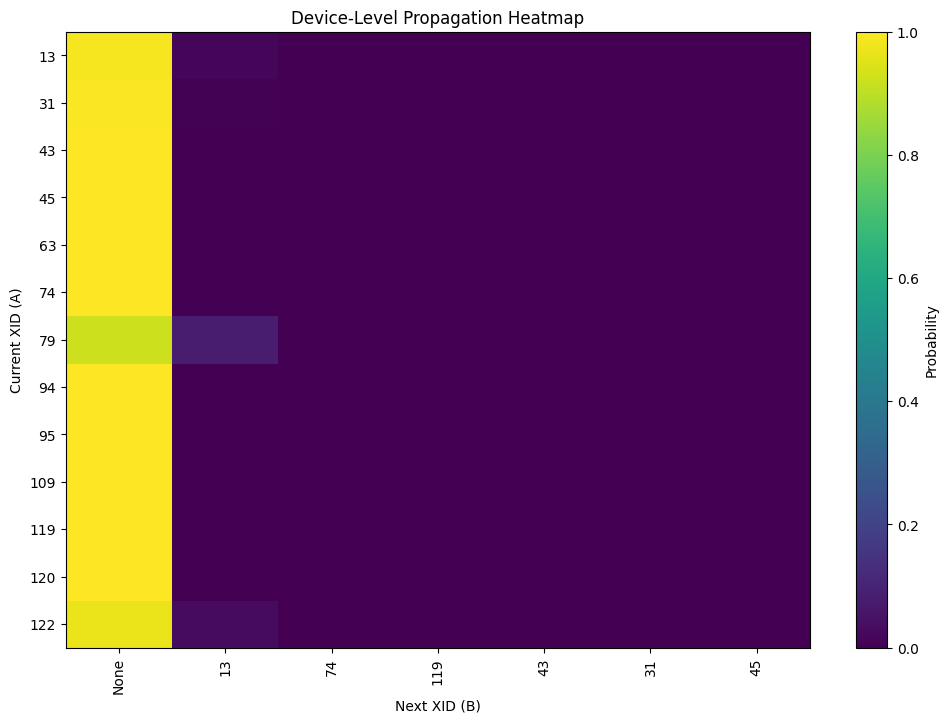

In [72]:
#5d
prop_df_dev = dataframe_2_coaleseced.copy()
prop_df_dev = prop_df_dev.sort_values('Timestamp').reset_index(drop=True)

counts_dev = defaultdict(lambda: defaultdict(int))

for i in range(len(prop_df_dev)):
    curr_row = prop_df_dev.loc[i]

    curr_xid = curr_row['XID']
    curr_time = curr_row['Timestamp']
    curr_node = curr_row['Node name']
    curr_device = curr_row['Device ID']

    found = False

    for j in range(i + 1, len(prop_df_dev)):
        next_row = prop_df_dev.loc[j]
        time_diff = next_row['Timestamp'] - curr_time

        if time_diff > 600:
            break

        if next_row['Node name'] == curr_node and next_row['Device ID'] == curr_device:
            next_xid = next_row['XID']
            counts_dev[curr_xid][next_xid] += 1
            found = True
            break

    if not found:
        counts_dev[curr_xid]['None'] += 1

prob_matrix_dev = {}

for xid_a in counts_dev:
    total = sum(counts_dev[xid_a].values())
    prob_matrix_dev[xid_a] = {}
    for xid_b in counts_dev[xid_a]:
        prob_matrix_dev[xid_a][xid_b] = counts_dev[xid_a][xid_b] / total

prob_df_dev = pd.DataFrame(prob_matrix_dev).fillna(0).T
prob_df_dev = prob_df_dev.sort_index()

print("Device-level propagation probability matrix:")
display(prob_df_dev)

plt.figure(figsize=(12, 8))
plt.imshow(prob_df_dev, aspect='auto')
plt.colorbar(label='Probability')

plt.xticks(range(len(prob_df_dev.columns)), prob_df_dev.columns, rotation=90)
plt.yticks(range(len(prob_df_dev.index)), prob_df_dev.index)

plt.xlabel('Next XID (B)')
plt.ylabel('Current XID (A)')
plt.title('Device-Level Propagation Heatmap')

plt.show()

In [73]:
#5e
print("The system-level analysis shows a lot more connections between XIDs, while the device-level analysis is mostly None, meaning errors usually don’t lead to another error on the same GPU. This suggests that many patterns at the system level come from activity across different nodes or devices, and that true local error propagation is actually pretty rare.")

The system-level analysis shows a lot more connections between XIDs, while the device-level analysis is mostly None, meaning errors usually don’t lead to another error on the same GPU. This suggests that many patterns at the system level come from activity across different nodes or devices, and that true local error propagation is actually pretty rare.
